In [3]:
import glob
import os
 
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap, LogNorm
from rasterio.enums import Resampling

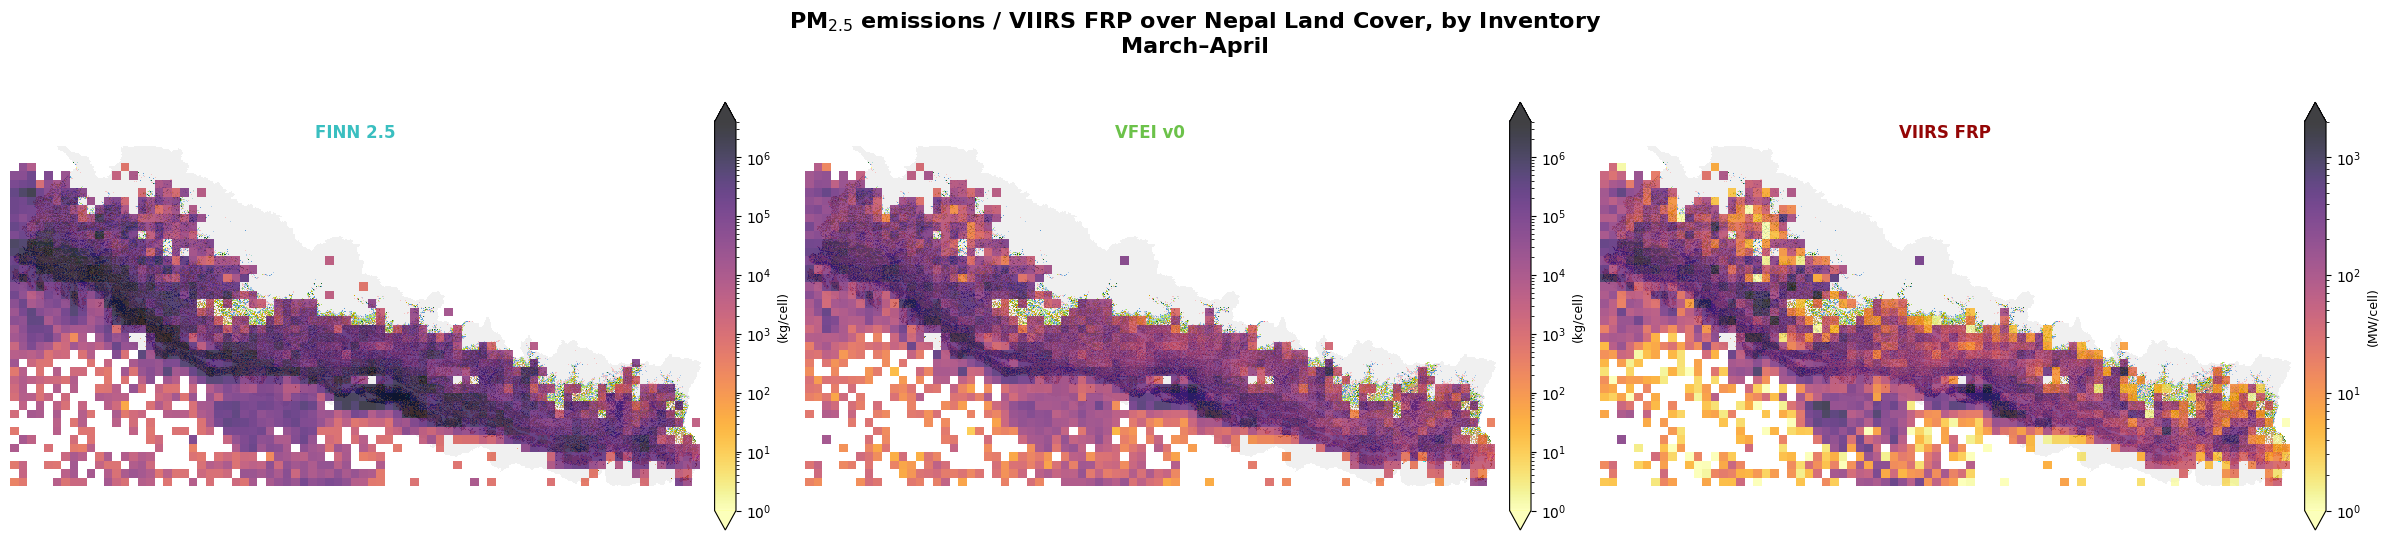

In [4]:
tifFile = "/Users/anehernandezarista/Holmes Summer 2026/Forest Types of Nepal/data/NepalForestType.tif"

forest_types = {
    1:  ("Abies mixed",                                   "#F2A883"),
    2:  ("Alnus sp.",                                     "#808080"),
    3:  ("Castanopsis lower temperate mixed broadleaved", "#C8A96E"),
    4:  ("Cool temperate mixed broadleaved",              "#3050A0"),
    5:  ("Dalbergia sissoo - senegalia catechu",          "#F5C4C4"),
    6:  ("Lower temperate mixed broadleaved",             "#5B9BD5"),
    7:  ("Lower temperate Quercus",                       "#A8C8E8"),
    8:  ("Pinus roxburghii",                              "#FFFFBF"),
    9:  ("Pinus roxburghii mixed broadleaved",            "#FFFF75"),
    10: ("Pinus roxburghii - shorea robusta",             "#A0B2D4"),
    11: ("Pinus wallichiana",                             "#A0A046"),
    12: ("Rhododendron arboreum",                         "#CC0000"),
    13: ("Schima sp.",                                    "#1A6B2A"),
    14: ("Shorea robusta",                                "#67A239"),
    15: ("Shorea robusta mixed broadleaved",              "#ADDE5A"),
    16: ("Subtropical mixed broadleaved",                 "#ACDDD1"),
    17: ("Temperate mixed broadleaved",                   "#D6BCDC"),
    18: ("Temperate Rhododendron mixed broadleaved",      "#9B30FF"),
    19: ("Terminalia tropical mixed broadleaved",         "#2BFAFA"),
    20: ("Tropical deciduous riverine",                   "#D4A800"),
    21: ("Tropical mixed broadleaved",                    "#996600"),
    22: ("Tropical riverine",                             "#5C2A00"),
    23: ("Upper temperate coniferous",                    "#FF6984"),
    24: ("Upper temperate Quercus",                       "#7B3FB5"),
    25: ("Warm temperate mixed broadleaved",              "#E8A0D0"),
    26: ("Non forest",                                    "#F0F0F0"),
}

with rasterio.open(tifFile) as ds:
    landcover = ds.read(1, out_shape=(ds.height // 3, ds.width // 3), resampling=Resampling.nearest).astype(float)
    lc_extent = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]
    raster_nodata = ds.nodata

n = 27
lc_colors = ["white"] * n
for val, (label, color) in forest_types.items():
    lc_colors[val] = color

lc_cmap = ListedColormap(lc_colors)
lc_cmap.set_bad(color="#000000")
lc_bounds = np.arange(-0.5, n + 0.5, 1)
lc_norm = BoundaryNorm(lc_bounds, lc_cmap.N)

# common grid for FINN, VFEI, VIIRS
LAT_MIN, LAT_MAX = 26.4, 30.4
LON_MIN, LON_MAX = 80.1, 88.2
RES = 0.1

lat_edges = np.arange(LAT_MIN, LAT_MAX + RES, RES)
lon_edges = np.arange(LON_MIN, LON_MAX + RES, RES)
lat_centers = lat_edges[:-1] + RES / 2
lon_centers = lon_edges[:-1] + RES / 2

MONTHS = {"March": ("2021-03-01", "2021-03-31"), "April": ("2021-04-01", "2021-04-30")}

PM25_VMIN, PM25_VMAX = 1, 4e6
FRP_VMIN, FRP_VMAX = 1, 2e3

#FINN 2.5 
finn_ds = xr.open_dataset("emissions-finnv2.5modvrs_PM25_bb_surface_daily_20210101-20211231_0.1x0.1.nc")

lat_ascending = bool(finn_ds.lat.values[0] < finn_ds.lat.values[-1])
lat_slice = slice(LAT_MIN, LAT_MAX) if lat_ascending else slice(LAT_MAX, LAT_MIN)
lon_ascending = bool(finn_ds.lon.values[0] < finn_ds.lon.values[-1])
lon_slice = slice(LON_MIN, LON_MAX) if lon_ascending else slice(LON_MAX, LON_MIN)

finn_sub = finn_ds.sel(time=slice("2021-03-01", "2021-04-30"), lat=lat_slice, lon=lon_slice)

R = 6371000.0 # Earth radius (m)
dlat = dlon = 0.1 * np.pi / 180 
cell_area = R**2 * dlon * dlat * np.cos(np.deg2rad(finn_sub.lat.values)) # m^2 per cell
area2d = np.repeat(cell_area[:, None], finn_sub.sizes["lon"], axis=1)

flux = finn_sub["fire_modisviirs_PM25"].values  # molecules cm-2 s-1
NA = 6.022e23
MW = 12.0 #g/mol
mass_flux = flux / NA * MW * 1e-3 * 1e4 * area2d[None, :, :] * 86400  # kg/day per cell

finn_monthly = {}
for month, (start, end) in MONTHS.items():
    idx = finn_sub.time.to_index().slice_indexer(start, end)
    finn_monthly[month] = mass_flux[idx].sum(axis=0)

finn_lat = finn_sub.lat.values
finn_lon = finn_sub.lon.values

#VFEI v0
vfei_files = sorted(glob.glob(os.path.join("VFEI v0 2021", "vfei_v0_0.005deg_*.nc")))

vfei_monthly = {"March": np.zeros((len(lat_centers), len(lon_centers))),
                 "April": np.zeros((len(lat_centers), len(lon_centers)))}
vfei_days_by_month = {"March": 0, "April": 0}

for f in vfei_files:
    datestr = os.path.basename(f).split("_")[-1].replace(".nc", "")
    date = pd.to_datetime(datestr, format="%Y%m%d")

    if date.year != 2021:
        continue
    if date.month == 3:
        month = "March"
    elif date.month == 4:
        month = "April"
    else:
        continue

    ds = xr.open_dataset(f)
    lat, lon = ds.lat.values, ds.lon.values
    daily_kg = ds.PM2_5.values * ds.grid_area.values * 86400
    
    lat_idx = np.digitize(lat, lat_edges) - 1 
    lon_idx = np.digitize(lon, lon_edges) - 1
    valid = (lat_idx >= 0) & (lat_idx < len(lat_centers)) & (lon_idx >= 0) & (lon_idx < len(lon_centers))

    np.add.at(vfei_monthly[month], (lat_idx[valid], lon_idx[valid]), daily_kg[valid])
    vfei_days_by_month[month] += 1
    ds.close()

#VIIRS FRP
viirs_raw = pd.read_excel("fire_archive_SV-C2_760260.xlsx")
viirs_raw["date"] = pd.to_datetime(viirs_raw["acq_date"])
viirs_raw = viirs_raw[viirs_raw["confidence"].isin(["n", "h"])]

viirs_monthly = {}
for month, (start, end) in MONTHS.items():
    sub = viirs_raw[(viirs_raw["date"] >= start) & (viirs_raw["date"] <= end)]
    grid = np.zeros((len(lat_centers), len(lon_centers)))
    lat_idx = np.digitize(sub["latitude"].values, lat_edges) - 1
    lon_idx = np.digitize(sub["longitude"].values, lon_edges) - 1
    valid = (lat_idx >= 0) & (lat_idx < len(lat_centers)) & (lon_idx >= 0) & (lon_idx < len(lon_centers))
    np.add.at(grid, (lat_idx[valid], lon_idx[valid]), sub["frp"].values[valid])
    viirs_monthly[month] = grid

finn_combined = finn_monthly["March"] + finn_monthly["April"]
vfei_combined = vfei_monthly["March"] + vfei_monthly["April"]
viirs_combined = viirs_monthly["March"] + viirs_monthly["April"]
vfei_days_combined = vfei_days_by_month["March"] + vfei_days_by_month["April"]

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 5.2), facecolor="white")

row_specs = [
    ("FINN 2.5", finn_combined, finn_lon, finn_lat,
     "(kg/cell)", PM25_VMIN, PM25_VMAX, "#3ABFC0"),
    ("VFEI v0", vfei_combined, lon_centers, lat_centers,
     "(kg/cell)", PM25_VMIN, PM25_VMAX, "#6CC24A"),
    ("VIIRS FRP", viirs_combined, lon_centers, lat_centers,
     "(MW/cell)", FRP_VMIN, FRP_VMAX, "#940606"),
]
 
for col, (name, data, lons, lats, cbar_label, vmin, vmax, title_color) in enumerate(row_specs):
    ax = axes[col]
    ax.set_facecolor("white")
 
    ax.imshow(landcover, cmap=lc_cmap, norm=lc_norm, extent=lc_extent, interpolation="nearest", zorder=1)
 
    plot_data = np.ma.masked_where(data <= 0, data)
 
    if plot_data.mask.all():
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=13,
                 transform=ax.transAxes, zorder=3,
                 bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
    else:
        im = ax.pcolormesh(lons, lats, plot_data, cmap="inferno_r",
                            norm=LogNorm(vmin=vmin, vmax=vmax),
                            shading="auto", alpha=0.75, zorder=2)
        cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, extend="both")
        cbar.set_label(cbar_label, fontsize=9)
 
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(name, fontsize=12, fontweight="bold", color=title_color)
 
fig.suptitle("PM$_{2.5}$ emissions / VIIRS FRP over Nepal Land Cover, by Inventory\nMarch\u2013April",
             fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()